In [2]:
# Import the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

# Load the data we created in Day 1
df = pd.read_csv('student_performance.csv')
print("\n✅ Loaded student data from Day 1")

print(f"\n📊 We have data for {len(df)} students")
print(f"📋 Columns: {list(df.columns)}")
print("\nFirst 5 students:")
print(df.head())

STUDENT PERFORMANCE PREDICTION

✅ Loaded student data from Day 1

📊 We have data for 500 students
📋 Columns: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score', 'extracurricular_encoded', 'parent_education_encoded', 'internet_access_encoded']

First 5 students:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   

  extracurricular parent_education internet_access  final_score  \
0             Yes           Master              No        86.71   
1              No         Bachelor             Yes        87.98  

In [5]:
# load iris data
iris_df = pd.read_csv('../data/iris.csv')
print("\n✅ Loaded Iris dataset")
print(f"\n📊 We have data for {len(iris_df)} iris samples")

# Explore the iris dataset
print("\nFirst 5 iris samples:")
print(iris_df.head())

print("\n📋 Iris Columns:", list(iris_df.columns))

print("\n📊 Statistics of Iris Dataset:")
print(iris_df.describe())


✅ Loaded Iris dataset

📊 We have data for 150 iris samples

First 5 iris samples:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

📋 Iris Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

📊 Statistics of Iris Dataset:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     

Sample of students:
--------------------------------------------------
   hours_studied  final_score
0              7        86.71
1              4        87.98
2             13       100.00
3             11       100.00
4              8        98.38
5             13       100.00
6              5        69.64
7              7        84.54
8             10       100.00
9              3        87.92

📊 Average scores by study hours:
--------------------------------------------------
hours_studied
1     75.7
2     74.4
3     77.2
4     83.3
5     85.7
6     84.5
7     88.4
8     91.8
9     93.7
10    94.9
11    97.4
12    96.8
13    96.6
14    97.7
Name: final_score, dtype: float64


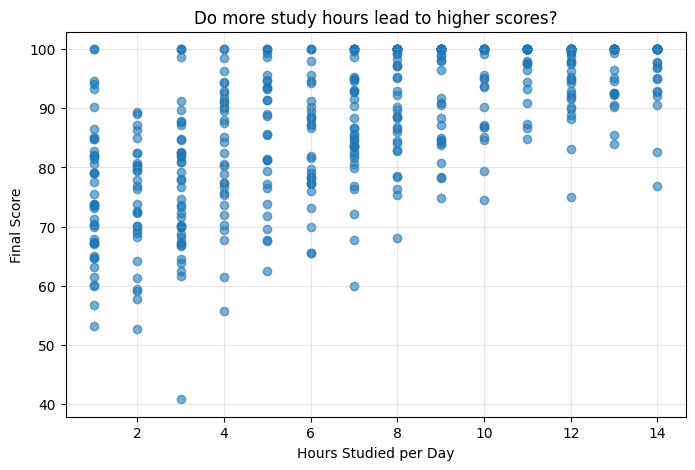


💡 What we see:
   - Students who study more tend to score higher
   - But it's not perfect (other factors matter too)
   - This is where our ML model will help!


In [6]:
# Look at a few students
print("Sample of students:")
print("-"*50)
print(df[['hours_studied', 'final_score']].head(10))

# Calculate average score for different study hours
print("\n📊 Average scores by study hours:")
print("-"*50)

# Group by hours studied and calculate average
avg_by_hours = df.groupby('hours_studied')['final_score'].mean().round(1)
print(avg_by_hours)

# Make a simple plot
plt.figure(figsize=(8, 5))
plt.scatter(df['hours_studied'], df['final_score'], alpha=0.6)
plt.xlabel('Hours Studied per Day')
plt.ylabel('Final Score')
plt.title('Do more study hours lead to higher scores?')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 What we see:")
print("   - Students who study more tend to score higher")
print("   - But it's not perfect (other factors matter too)")
print("   - This is where our ML model will help!")

In [7]:
# Select our feature (what we know) and target (what we want to predict)
feature = ['hours_studied']  # We'll use study hours to predict
target = 'final_score'        # What we want to predict

X = df[feature]  # Features (input)
y = df[target]   # Target (output)

print("✅ Features (what we know):")
print(X.head())
print("\n✅ Target (what we want to predict):")
print(y.head())

print(f"\n📊 We have {len(X)} students")
print(f"   Each student has {len(feature)} feature: study hours")

✅ Features (what we know):
   hours_studied
0              7
1              4
2             13
3             11
4              8

✅ Target (what we want to predict):
0     86.71
1     87.98
2    100.00
3    100.00
4     98.38
Name: final_score, dtype: float64

📊 We have 500 students
   Each student has 1 feature: study hours


## 📊 Step 4: Split Data for Training and Testing

**Why split?**
- We need to test if our model works on NEW students it hasn't seen
- Train: 80% of students (model learns from them)
- Test: 20% of students (we check if model predicts correctly)

In [8]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Data Split:")
print(f"   Training set: {len(X_train)} students (80%)")
print(f"   Testing set: {len(X_test)} students (20%)")

print(f"\n📚 Training students (first 5):")
print(X_train.head())

print(f"\n🎯 Their scores (first 5):")
print(y_train.head())

📊 Data Split:
   Training set: 400 students (80%)
   Testing set: 100 students (20%)

📚 Training students (first 5):
     hours_studied
249             12
433              3
19               6
322             14
332              2

🎯 Their scores (first 5):
249    100.00
433    100.00
19      94.60
322    100.00
332     68.94
Name: final_score, dtype: float64


In [9]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model training complete!")
print("\n📐 The model found this formula:")

# Get the numbers the model learned
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"   Predicted Score = {coefficient:.2f} × (Study Hours) + {intercept:.2f}")
print(f"\n💡 This means:")
print(f"   - Base score (0 study hours): {intercept:.1f} points")
print(f"   - Each study hour adds: {coefficient:.2f} points")
print(f"   - If a student studies 5 hours: {5 * coefficient + intercept:.1f} points")
print(f"   - If a student studies 10 hours: {10 * coefficient + intercept:.1f} points")

✅ Model training complete!

📐 The model found this formula:
   Predicted Score = 1.96 × (Study Hours) + 73.51

💡 This means:
   - Base score (0 study hours): 73.5 points
   - Each study hour adds: 1.96 points
   - If a student studies 5 hours: 83.3 points
   - If a student studies 10 hours: 93.1 points


## 📈 Step 6: Make Predictions

Let's use our model to predict scores for the test students

In [10]:
# Make predictions on test data
predictions = model.predict(X_test)

# Create a simple table to compare
results = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': predictions.round(1),
    'Difference': abs(y_test.values - predictions).round(1)
})

print("📊 Comparing Predictions vs Actual:")
print("-"*50)
print(results.head(10))
print("-"*50)

# Calculate average error
avg_error = results['Difference'].mean()
print(f"\n📊 Average prediction error: {avg_error:.1f} points")
print(f"   (This means on average, we're off by {avg_error:.1f} points)")

📊 Comparing Predictions vs Actual:
--------------------------------------------------
   Actual Score  Predicted Score  Difference
0        100.00            100.9         0.9
1         83.96             99.0        15.0
2         92.90             81.3        11.6
3        100.00             89.2        10.8
4         97.24             89.2         8.1
5         97.03            100.9         3.9
6         67.85             75.5         7.6
7         59.91             75.5        15.6
8         61.43             81.3        19.9
9         84.13             89.2         5.1
--------------------------------------------------

📊 Average prediction error: 7.4 points
   (This means on average, we're off by 7.4 points)


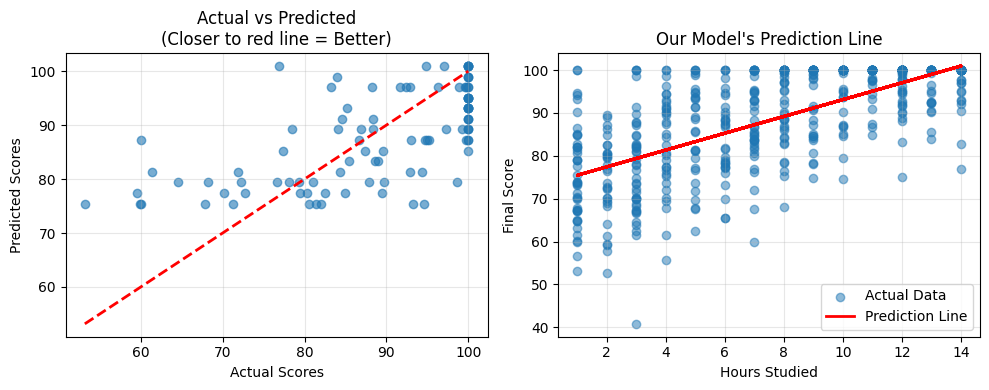

💡 What these graphs show:
   Left: Points close to red line = good predictions
   Right: The red line is our model - it predicts scores based on study hours


In [11]:
# Create a plot to see how well our model predicts
plt.figure(figsize=(10, 4))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted\n(Closer to red line = Better)')
plt.grid(True, alpha=0.3)

# Plot 2: The regression line
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.5, label='Actual Data')
plt.plot(X_test, predictions, 'r-', linewidth=2, label='Prediction Line')
plt.xlabel('Hours Studied')
plt.ylabel('Final Score')
plt.title('Our Model\'s Prediction Line')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 What these graphs show:")
print("   Left: Points close to red line = good predictions")
print("   Right: The red line is our model - it predicts scores based on study hours")

In [12]:
# Calculate simple metrics to understand model quality

# 1. Mean Absolute Error (MAE) - Average error in points
mae = mean_absolute_error(y_test, predictions)

# 2. R-squared - How much variance we explain (0 to 1, higher is better)
r2 = r2_score(y_test, predictions)

print("📊 Model Performance Report:")
print("="*40)
print(f"✓ Mean Absolute Error (MAE): {mae:.1f} points")
print(f"  → On average, our prediction is off by {mae:.1f} points")

print(f"\n✓ R-squared (R²): {r2:.3f}")
print(f"  → Our model explains {r2*100:.1f}% of why students get different scores")

# Simple interpretation
if r2 > 0.7:
    print("\n🎉 Great! The model is working very well!")
elif r2 > 0.5:
    print("\n👍 Good! The model captures the main pattern")
else:
    print("\n📝 The model is simple but gives us a basic understanding")

📊 Model Performance Report:
✓ Mean Absolute Error (MAE): 7.4 points
  → On average, our prediction is off by 7.4 points

✓ R-squared (R²): 0.411
  → Our model explains 41.1% of why students get different scores

📝 The model is simple but gives us a basic understanding
